## Read data and plot images

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep +'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()
case = path.split(os.sep)[-1]
print(path, case)

aln = ALNModel()
data.set_parameters(aln)
state_vars = aln.state_vars

not here
/mnt/antares_raid/home/salfenmoser/neurolib/GUI/gui/data/00001 00001


In [2]:
def set_target_init(exc_, inh_, max_I):
    
    initVars_ = [None] * len(exc_)
    target_ = [None] * len(exc_)
    
    for i in range(len(exc_)):
        aln.params.mue_ext_mean = exc_[i] * 5. 
        aln.params.mui_ext_mean = inh_[i] * 5.

        aln.params.duration = 3000.

        control0 = aln.getZeroControl()
        control0 = functions.step_control(aln, maxI_ = max_I[0])
        aln.run(control=control0)

        target_rates = np.zeros((2))
        target_rates[0] = aln.rates_exc[0,-1] 
        target_rates[1] = aln.rates_inh[0,-1]

        control0 = functions.step_control(aln, maxI_ = max_I[1])
        aln.run(control=control0)

        init_state_vars = np.zeros(( len(state_vars) ))
        for j in range(len(state_vars)):
            if aln.state[state_vars[j]].size == 1:
                init_state_vars[j] = aln.state[state_vars[j]][0]
            else:
                init_state_vars[j] = aln.state[state_vars[j]][0,-1]

        initVars_[i] = init_state_vars

        aln.params.duration = dur
        target_[i] = aln.getZeroTarget()
        target_[i][:,0,:] = target_rates[0]
        target_[i][:,1,:] = target_rates[1]
    
    return initVars_, target_

In [3]:
data_array = data.read_data(path, case)
exc_, inh_, no_c_, both_c_ = data_array[0:4]
exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2 = data_array[4:12]
exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost = data_array[12:]

with open(path + os.sep + 'bi.pickle','rb') as f:
    load_array= pickle.load(f)
ext_exc = load_array[0]
ext_inh = load_array[1]

[bestControl_init, costnode_init, bestControl_0, costnode_0] = data.read_control(path, case)

dur = 100
dur_pre = 10
dur_post = 10

trans_time = 0.8

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.] 
    
path_directory = path.split(os.sep + 'data')[0] + os.sep + 'plots_' 
try:
    os.stat(path_directory)
except:
    os.mkdir(path_directory)
    
path_directory = path_directory + os.sep + case
try:
    os.stat(path_directory)
except:
    os.mkdir(path_directory)

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/gui/plots_/00001/1
40
80
150


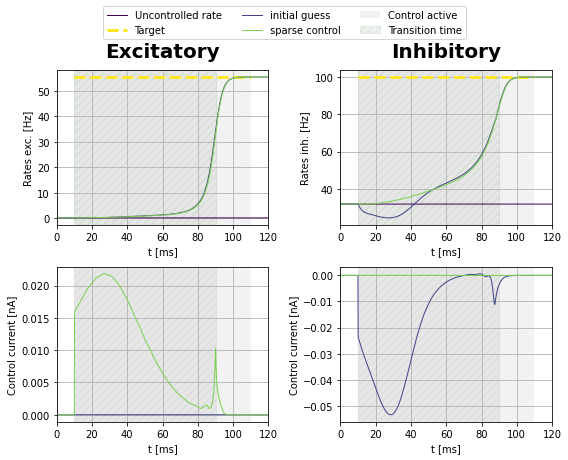

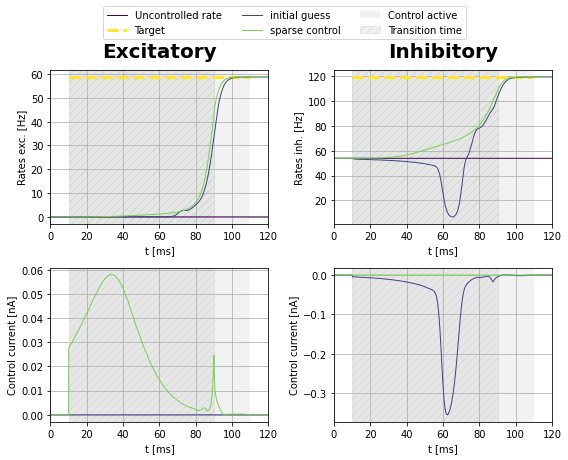

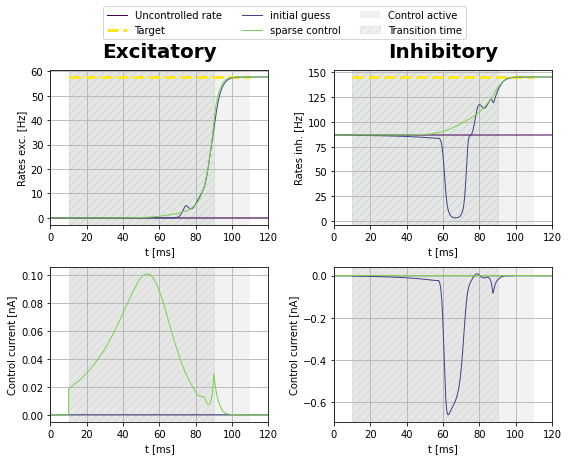

In [4]:
initVars_1, target_1 = set_target_init(exc_1, inh_1, max_I)

path1 = path_directory + os.sep + '1'
print(path1)

try:
    os.stat(path1)
except:
    os.mkdir(path1) 

for i in range(len(exc_1)):
    file_ = str(i)
    aln.params.mue_ext_mean = exc_1[i] * 5.
    aln.params.mui_ext_mean = inh_1[i] * 5.
    
    for j in range(len(ext_exc)):
        if j in exc_:
            #print(i, j)
            if exc_1[i] == ext_exc[j] and inh_1[i] ==  ext_inh[j]:
                index_ = j
                print(j)
                break
    
    plotFunc.plot_control_current(aln, [bestControl_init[index_], bestControl_0[index_]],
        [costnode_init[index_], costnode_0[index_]], [[1.,0.,1.], [1.,0.,1.]], dur,
        dur_pre, dur_post, initVars_1[i], target_1[i], path1, filename_ = file_, transition_time_ = trans_time,
        labels_ = ["initial guess", "sparse control"], print_cost_=False)

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/gui/plots_/00001/2
0
10
20
30
50
60
110


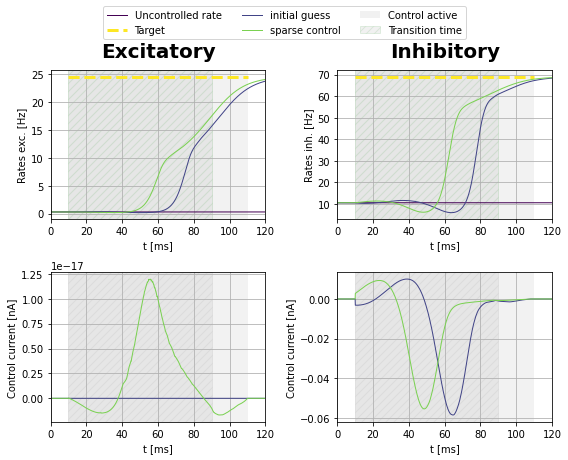

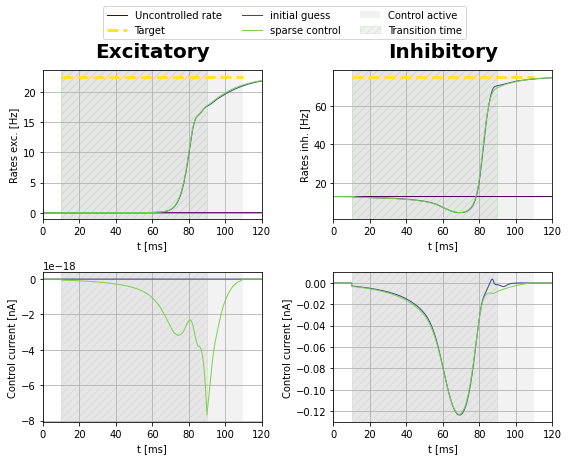

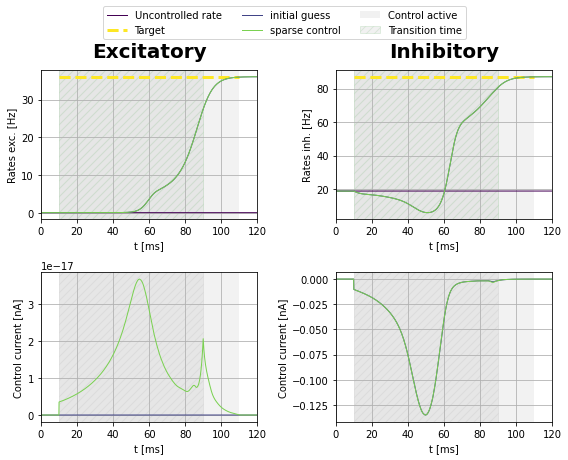

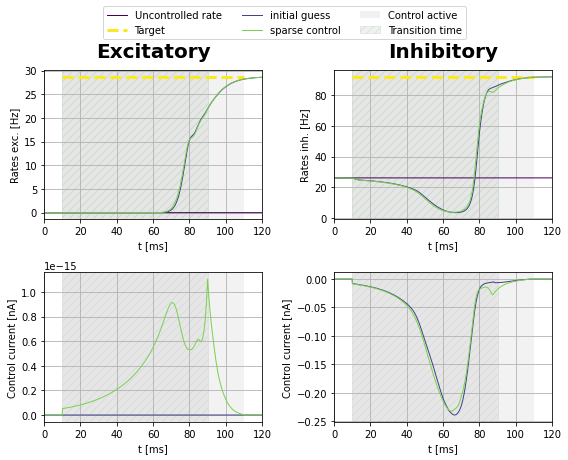

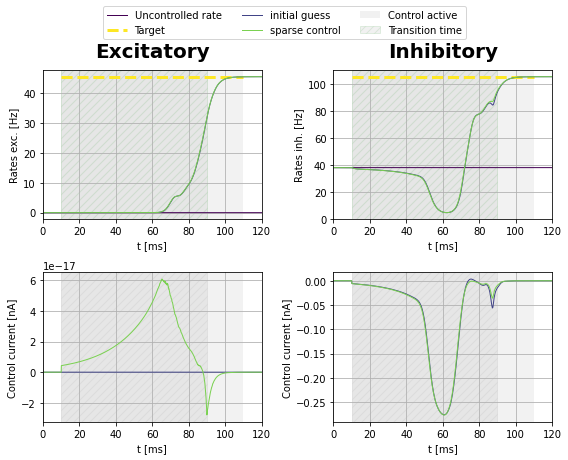

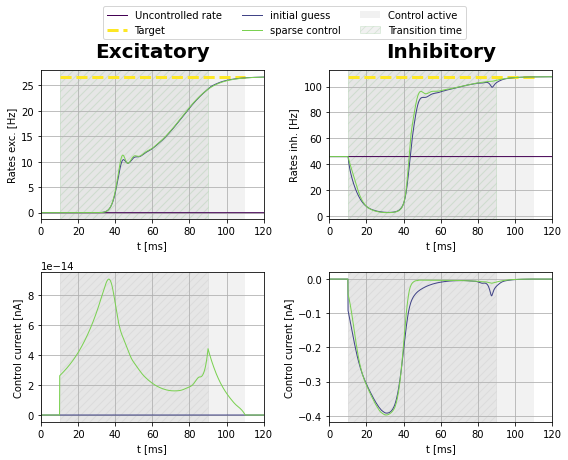

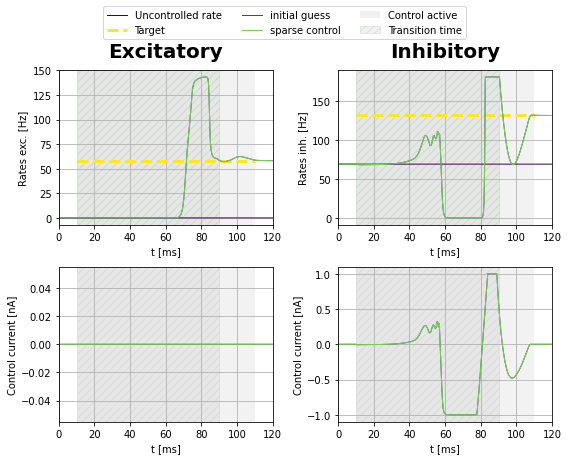

In [5]:
initVars_2, target_2 = set_target_init(exc_2, inh_2, max_I)

path2 = path_directory + os.sep + '2'
print(path2)

try:
    os.stat(path2)
except:
    os.mkdir(path2) 

for i in range(len(exc_2)):
    file_ = str(i)
    aln.params.mue_ext_mean = exc_2[i] * 5.
    aln.params.mui_ext_mean = inh_2[i] * 5.
    
    for j in range(len(ext_exc)):
        if j in inh_:
            #print(i, j)
            if exc_2[i] == ext_exc[j] and inh_2[i] ==  ext_inh[j]:
                index_ = j
                print(j)
                break
    
    plotFunc.plot_control_current(aln, [bestControl_init[index_], bestControl_0[index_]],
        [costnode_init[index_], costnode_0[index_]], [[1.,0.,1.], [1.,0.,1.]], dur,
        dur_pre, dur_post, initVars_2[i], target_2[i], path2, filename_ = file_, transition_time_ = trans_time,
        labels_ = ["initial guess", "sparse control"], print_cost_=False)

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/gui/plots_/00001/1


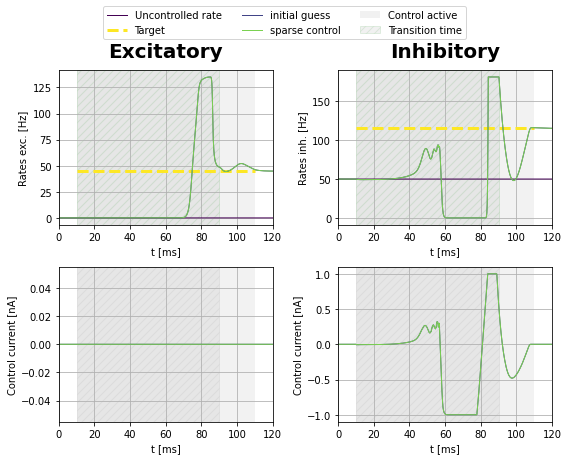

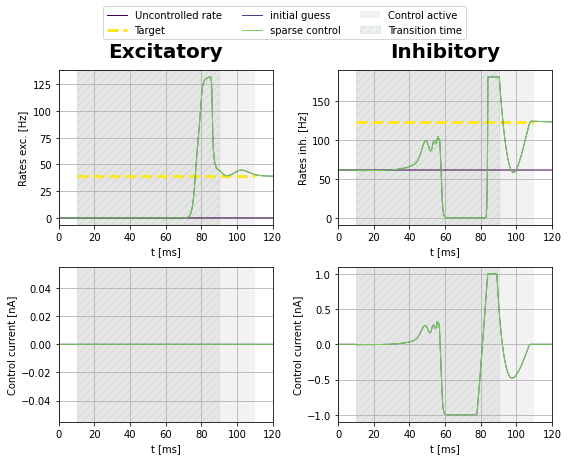

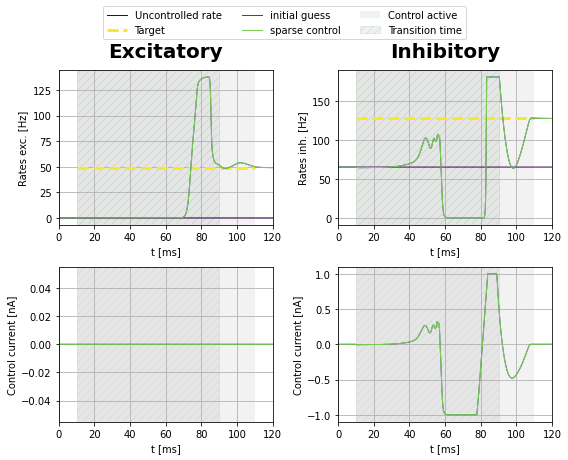

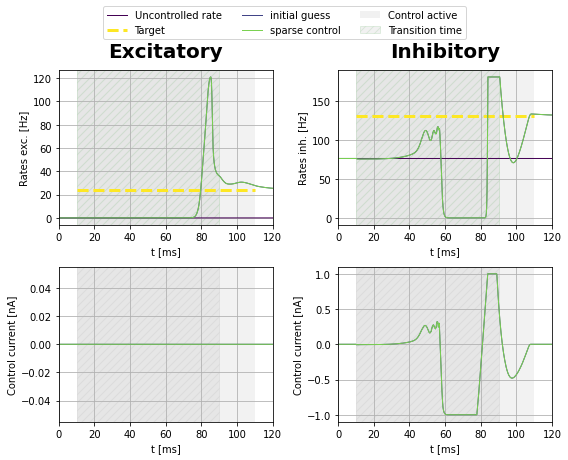

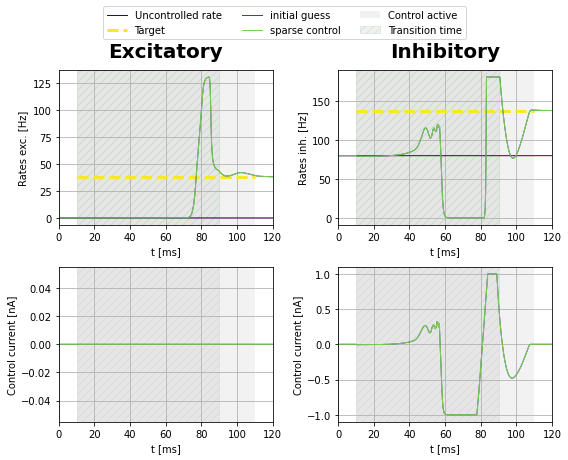

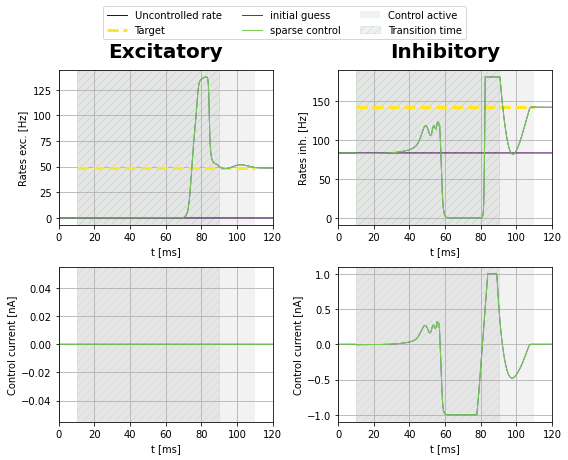

In [6]:
initVars_3, target_3 = set_target_init(exc_3, inh_3, max_I)

path3 = path_directory + os.sep + '3'
print(path1)

try:
    os.stat(path3)
except:
    os.mkdir(path3) 

for i in range(len(exc_3)):
    file_ = str(i)
    aln.params.mue_ext_mean = exc_3[i] * 5.
    aln.params.mui_ext_mean = inh_3[i] * 5.
    
    for j in range(len(ext_exc)):
        if j in no_c_:
            print(i, j)
            if exc_3[i] == ext_exc[j] and inh_3[i] ==  ext_inh[j]:
                index_ = j
                print(j)
                break
    
    plotFunc.plot_control_current(aln, [bestControl_init[index_], bestControl_0[index_]],
        [costnode_init[index_], costnode_0[index_]], [[1.,0.,1.], [1.,0.,1.]], dur,
        dur_pre, dur_post, initVars_3[i], target_3[i], path3, filename_ = file_, transition_time_ = trans_time,
        labels_ = ["initial guess", "sparse control"], print_cost_=False)

In [7]:
initVars_4, target_4 = set_target_init(exc_4, inh_4, max_I)

path4 = path_directory + os.sep + '4'
print(path4)

try:
    os.stat(path1)
except:
    os.mkdir(path1) 

for i in range(len(exc_4)):
    file_ = str(i)
    aln.params.mue_ext_mean = exc_4[i] * 5.
    aln.params.mui_ext_mean = inh_4[i] * 5.
    
    for j in range(len(ext_exc)):
        if j in both_c_:
            print(i, j)
            if exc_4[i] == ext_exc[j] and inh_4[i] ==  ext_inh[j]:
                index_ = j
                print(j)
                break
                
    print(np.amin(bestControl_0[index_][0,1,:]), np.amax(bestControl_0[index_][0,1,:]))
    
    plotFunc.plot_control_current(aln, [bestControl_init[index_], bestControl_0[index_]],
        [costnode_init[index_], costnode_0[index_]], [[1.,0.,1.], [1.,0.,1.]], dur,
        dur_pre, dur_post, initVars_4[i], target_4[i], path4, filename_ = file_, transition_time_ = trans_time,
        labels_ = ["initial guess", "sparse control"], print_cost_=False)

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/gui/plots_/00001/4
